# Joint Factor×Execution Evolution — Walkthrough (J0–J4)

The **outer layer** that turns the two evolutionary arms (factor programs and
execution programs) into a *joint* optimisation — RD-Agent(Q)-style
block-coordinate alternation with the statistics RD-Agent lacks. Everything here
runs **offline, in-process** (`QF_USE_MCP=0`), no LLM (both arms jitter-only),
no market data.

The pieces, each demonstrated in isolation below:

| Piece | What it does | Where |
| --- | --- | --- |
| `SOTAState` | the shared state the arms evolve against: curated book ↔ best executor ↔ frozen-signal version | `joint_evolution/state.py` |
| `TrialsLedger` | per-family gate counts + the joint VAL-look count (the honesty layer) | `ledger.py` |
| block protocol | one arm evolves G generations against the other's frozen state | `blocks.py` |
| re-freeze | factor block done → new book → freeze v(k+1) (poison-audited) → exec archive re-scored | `refreeze.py` |
| joint objective J | deflated net VAL Sharpe of book → combined model → executor → costs | `objective.py` + MCP `score_joint_state` |
| schedulers | sequential / round-robin / random / **contextual TS bandit** | `scheduler.py`, `bandit.py` |
| walk-forward | the WHOLE outer loop re-runs per fold; touch-once OOS scoring | `walkforward.py` |

Design anchor: `docs/joint-evolution/DESIGN.md`. Why this shape: RD-Agent(Q)
(NeurIPS 2025) is **not** one population — it is alternation over frozen SOTA
state with a bandit picking the next arm. We keep that skeleton and replace its
weak overfitting control with a shared cross-arm trials ledger, deflation
everywhere, and the joint walk-forward.


In [1]:
# ── setup: synthetic AR(1) panel + in-process service wiring (as in the tests) ──
import json, os, sys, tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
os.environ["QF_USE_MCP"] = "0"

N_BARS, TICKERS = 480, ["A", "B", "C", "D", "E", "F"]
rng = np.random.default_rng(3)
rets = np.zeros((N_BARS, len(TICKERS)))
eps = rng.standard_normal((N_BARS, len(TICKERS))) * 0.01
for t in range(1, N_BARS):
    rets[t] = 0.6 * rets[t - 1] + eps[t]
idx = pd.date_range("2024-01-01", periods=N_BARS, freq="D")
close = pd.DataFrame(100 * np.cumprod(1 + rets, axis=0), index=idx, columns=TICKERS)
PANEL = {"close": close}

from quant_fund_agent.mcp import research_service as svc
svc._load_panel_cached = lambda data_dir, fields, n_tickers: PANEL
svc._panel_cache_key = lambda data_dir, fields, n_tickers: ("joint-walkthrough",)

# keep the factor arm hermetic (no factor-DB reads)
from quant_fund_agent.agents.factor_research.evolution.loop import EvolutionLoop
EvolutionLoop._load_known_ids = lambda self: None

WORKDIR = Path(tempfile.mkdtemp(prefix="joint_walkthrough_"))
print("ready | workdir:", WORKDIR)


ready | workdir: /var/folders/0b/tfp69kqx3697_bkgxskvksmr0000gn/T/joint_walkthrough_6ypgsygg


## 1. The ledger: two statistically different counts

* **Family counts** (`n_factor`, `n_exec`) drive each arm's own deflation gates —
  factor ICs and executor Sharpes are different test families with different
  nulls; cross-billing would be wrong AND would break byte-identity of the
  standalone baselines.
* **The joint look count** bills *every* VAL read — including archive
  **re-scores** after a re-freeze and the block-boundary objective scores — and
  is what the final publish filter / touch-once TEST deflate by.
  Invariant: `n_joint_looks ≥ n_factor + n_exec`.


In [2]:
from quant_fund_agent.joint_evolution.ledger import TrialsLedger

led = TrialsLedger()
led.bill("factor", 5)                 # 5 new factor hypotheses
led.bill("exec", 3)                   # 3 new executor hypotheses
led.bill("exec", 4, rescore=True)     # exec archive re-scored after a re-freeze
led.bill_look(2, source="joint_objective")   # two block-boundary J scores
print(f"n_factor={led.n_factor}  n_exec={led.n_exec}  "
      f"n_joint_looks={led.joint_count()}  (≥ {led.n_factor + led.n_exec})")


n_factor=5  n_exec=3  n_joint_looks=14  (≥ 8)


## 2. A full joint run (round-robin, 3 blocks)

Block 0 is always **factor** (the exec arm needs a book to freeze evaluation
signals from). Watch the boundary protocol per block:
factor block → **re-freeze** (new book → `frozen_signals/v(k+1)`, poison-audited
→ exec archive re-scored, billing looks only); exec block → **SOTA-executor
update**. After every boundary the deterministic joint objective **J** (deflated
net VAL Sharpe of book → combined model → executor → costs) is scored — ΔJ is
the scheduler's reward.


In [3]:
from quant_fund_agent.agents.execution_research.evolution.loop import ExecEvolutionRunConfig
from quant_fund_agent.agents.factor_research.evolution.genome import FactorProgram
from quant_fund_agent.agents.factor_research.evolution.loop import EvolutionRunConfig
from quant_fund_agent.joint_evolution.loop import JointEvolutionLoop, JointRunConfig

FACTOR_TMPL = '''\
# factor {fid}

from __future__ import annotations

import pandas as pd

from quant_fund_agent.factors.base import BaseFactor
from quant_fund_agent.factors.ops import stddev, ts_mean
from quant_fund_agent.factors.registry import register_factor


@register_factor
class F_{fid}(BaseFactor):
    factor_id = "{fid}"
    name = "{fid}"
    category = "momentum"
    inputs = ["close"]
    prediction_horizon = 1

    def calc(self, data):
        close = data["close"]
        return {body}
'''

def seeds():
    return [
        FactorProgram(factor_id="jw_mom",
                      code=FACTOR_TMPL.format(fid="jw_mom", body="ts_mean(close.pct_change(), 3).fillna(0.0)"),
                      name="mom", category="momentum", expected_sign=1, prediction_horizon=1),
        FactorProgram(factor_id="jw_vol",
                      code=FACTOR_TMPL.format(fid="jw_vol", body="stddev(close.pct_change(), 12).fillna(0.0)"),
                      name="vol", category="volatility", expected_sign=1, prediction_horizon=1),
    ]

def factor_cfg(out):
    return EvolutionRunConfig(
        generations=1, population_size=6, children_per_generation=3, seed=11,
        target_horizon=1, cpcv_groups=4, cpcv_k=1, n_tickers=None,
        p_llm_semantic=0.0, p_crossover=0.0, p_jitter=1.0, out_dir=str(out))

def exec_cfg(out):
    return ExecEvolutionRunConfig(
        out_dir=str(out), signals_manifest="(joint)", generations=1,
        population_size=6, children_per_generation=3, seed=7, n_tickers=None)

joint = JointEvolutionLoop(
    JointRunConfig(out_dir=str(WORKDIR / "rr"), total_blocks=3, gens_per_block=1,
                   scheduler="round_robin", target_horizon=1, n_tickers=None),
    factor_cfg(WORKDIR / "a"), exec_cfg(WORKDIR / "b"), data_context="CTX")
summary = joint.run(initial_factor_programs=seeds())
print(json.dumps({k: v for k, v in summary.items() if k != "ledger"}, indent=2, default=str))
print("ledger:", {k: summary["ledger"][k] for k in ("n_factor", "n_exec", "n_joint_looks")})


{
  "blocks": 3,
  "scheduler": "round_robin",
  "J": 0.399105091093137,
  "book_size": 3,
  "frozen_signals_version": 2,
  "sota_executor": "ex1_1_d781",
  "arm_choices": [
    "factor",
    "exec",
    "factor"
  ],
  "elapsed_sec": 8.2
}
ledger: {'n_factor': 6, 'n_exec': 5, 'n_joint_looks': 19}


In [4]:
# blocks.jsonl = the OUTER lineage: one row per block, fully auditable
rows = [json.loads(l) for l in (WORKDIR / "rr" / "blocks.jsonl").read_text().splitlines()]
pd.DataFrame([{
    "block": r["block"], "arm": r["arm"], "scored": r["candidates_scored"],
    "J_after": r["J_after"], "reward": r["reward"],
    "frozen_v": r["frozen_signals_version"], "sota_exec": r["sota_executor"],
    "refrozen": (r["boundary"] or {}).get("refrozen"),
    "rescored": ((r["boundary"] or {}).get("rescore") or {}).get("rescored"),
} for r in rows])


,block,arm,scored,J_after,reward,frozen_v,sota_exec,refrozen,rescored
0,0,factor,4,0.357390,NaN,1,NaN,True,NaN
1,1,exec,5,0.423397,0.066008,1,ex1_1_d781,None,NaN
2,2,factor,2,0.399105,-0.024292,2,ex1_1_d781,True,5.0


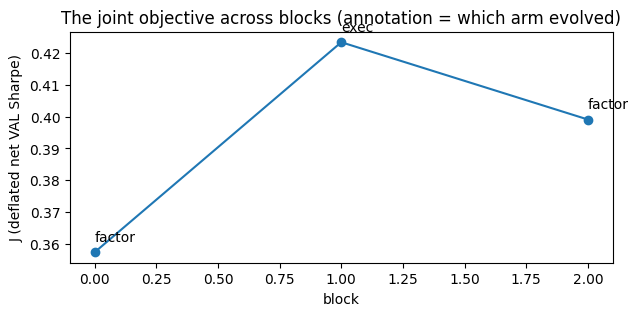

In [5]:
fig, ax = plt.subplots(figsize=(7, 3))
J = [r["J_after"] for r in rows]
ax.plot(range(len(J)), J, marker="o")
for i, r in enumerate(rows):
    ax.annotate(r["arm"], (i, J[i]), textcoords="offset points", xytext=(0, 8))
ax.set_xlabel("block"); ax.set_ylabel("J (deflated net VAL Sharpe)")
ax.set_title("The joint objective across blocks (annotation = which arm evolved)");


### 2b. Everything persists — a joint run resumes mid-schedule

`joint_state.json` carries the SOTA state + ledger + scheduler posterior;
extending `total_blocks` and re-running executes ONLY the remaining blocks.


In [6]:
from dataclasses import replace
resumed = JointEvolutionLoop(
    replace(joint.cfg, total_blocks=4),
    factor_cfg(WORKDIR / "a"), exec_cfg(WORKDIR / "b"), data_context="CTX")
s2 = resumed.run()
print("blocks now:", s2["blocks"], "| arm choices:", s2["arm_choices"])


blocks now: 4 | arm choices: ['factor', 'exec', 'factor', 'exec']


## 3. The schedulers — including the RD-Agent(Q)-style bandit

`sequential` (the original two-stage plan), `round_robin` (the default),
`random` (RD-Agent's ablation control) and the **contextual Thompson-sampling
bandit**: one Bayesian linear regression per arm, reward = the block's deflated
ΔJ, warmup forces one observation per arm, and the posterior persists. On a
synthetic reward stream where the factor arm is genuinely better, the bandit
finds it within ~10 decisions — with only ~5–15 block decisions per thesis run,
that cold-start behaviour is the whole game.


sequential : ['factor', 'factor', 'factor', 'exec', 'exec']
round_robin: ['factor', 'exec', 'factor', 'exec', 'factor']
random     : ['factor', 'factor', 'exec', 'exec', 'factor']


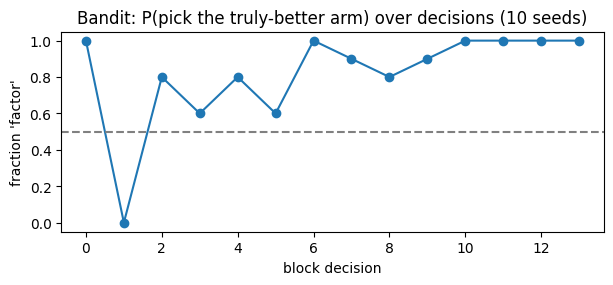

In [7]:
from quant_fund_agent.joint_evolution.bandit import BanditScheduler
from quant_fund_agent.joint_evolution.scheduler import make_scheduler

print("sequential :", [make_scheduler("sequential", total_blocks=5).pick(b, []) for b in range(5)])
print("round_robin:", [make_scheduler("round_robin", total_blocks=5).pick(b, []) for b in range(5)])
print("random     :", [make_scheduler("random", total_blocks=5, seed=7).pick(b, []) for b in range(5)])

def simulate_bandit(seed, n=14):
    b = BanditScheduler(seed=seed)
    history, choices = [], []
    for k in range(n):
        arm = "factor" if k == 0 else b.pick(k, history)
        r = 0.10 if arm == "factor" else -0.10     # factor arm is truly better
        b.update(arm, r)
        history.append({"arm": arm, "J_after": r, "reward": r,
                        "joint_score": {"val_net_sharpe": r},
                        "frozen_signals_version": 1})
        choices.append(arm)
    return choices

runs = [simulate_bandit(s) for s in range(10)]
frac_factor = np.mean([[c == "factor" for c in run] for run in runs], axis=0)
plt.figure(figsize=(7, 2.6))
plt.plot(frac_factor, marker="o")
plt.axhline(0.5, ls="--", c="grey")
plt.title("Bandit: P(pick the truly-better arm) over decisions (10 seeds)")
plt.xlabel("block decision"); plt.ylabel("fraction 'factor'");


## 4. The coupling (J3): execution-aware factor fitness

With `coupling=on`, the factor arm's `cost_ok` gate trades every candidate
**through the current SOTA executor** (net-of-cost return must be positive),
and a `net_capture_sota` diagnostic feeds the reflection brief — so alpha search
becomes execution-aware without touching the 5-axis Pareto geometry.
`cost_executor=None` is byte-identical to the baseline (test-enforced).


In [8]:
from quant_fund_agent.research_eval.harness import EvalParams, evaluate_candidate
from quant_fund_agent.research_eval.splits import three_way_split
from quant_fund_agent.agents.execution_research.evolution.seeds import ZTHRESH_SEED_CODE

split = three_way_split(close.index)
cand = close.pct_change().fillna(0.0)          # the momentum candidate
from quant_fund_agent.comparison.config import ComparisonConfig
cfg = ComparisonConfig(preruns=["nb"], target_horizon=1,
                       fit_standardize="per_underlying", seed=0)

sota = {"executor_id": "seed_zscore_threshold", "code": ZTHRESH_SEED_CODE}
res_off = evaluate_candidate(cand, [], PANEL, cfg, split, params=EvalParams())
res_on = evaluate_candidate(cand, [], PANEL, cfg, split,
                            params=EvalParams(cost_executor=sota))
print("coupling off → diagnostics keys unchanged:",
      "net_capture_sota" not in res_off.diagnostics)
print("coupling on  → net_capture_sota =", res_on.diagnostics["net_capture_sota"],
      "| cost_ok =", res_on.gates.cost_ok)


coupling off → diagnostics keys unchanged: True
coupling on  → net_capture_sota = 0.9489660888336136 | cost_ok = True


## 5. The headline protocol (J4): the joint walk-forward

For each fold boundary `d_i`, a **fresh** joint loop (own ledger, own scheduler
posterior) re-runs the WHOLE search with `cutoff_date = d_i`, and the final
(book, executor) pair is scored **once** on `[d_i, d_{i+1})` — so the reported
OOS numbers never saw the search's VAL window, and the scheduler's adaptivity is
priced by construction rather than by a correction.


In [9]:
from quant_fund_agent.joint_evolution.walkforward import run_joint_walk_forward

wf = run_joint_walk_forward(
    JointRunConfig(out_dir="ignored", total_blocks=2, gens_per_block=1,
                   scheduler="round_robin", target_horizon=1, n_tickers=None),
    factor_cfg(WORKDIR / "wa"), exec_cfg(WORKDIR / "wb"),
    ["2025-01-01", "2025-03-01"],
    out_dir=WORKDIR / "wf", data_context="CTX",
    initial_factor_programs=seeds())

pd.DataFrame([{
    "fold": f["fold"], "cutoff": f["cutoff"], "score_window": f"[{f['score_start']}, {f['score_end'] or '∞'})",
    "oos_net_sharpe": f["oos"].get("oos_net_sharpe"),
    "oos_ic": f["oos"].get("oos_ic"),
    "capture": f["oos"].get("capture"),
    "n_oos_bars": f["oos"].get("n_oos_bars"),
} for f in wf["folds"]])


,fold,cutoff,score_window,oos_net_sharpe,oos_ic,capture,n_oos_bars
0,0,2025-01-01,"[2025-01-01, 2025-03-01)",0.305515,0.486766,0.838971,58
1,1,2025-03-01,"[2025-03-01, ∞)",0.715650,0.540185,0.927567,54


## Wrap-up — the experiment matrix these pieces enable

| Arm | Command sketch |
| --- | --- |
| sequential (the two-stage plan) | `--scheduler sequential` |
| round-robin joint | `--scheduler round_robin` |
| random control (RD-Agent's ablation) | `--scheduler random` |
| bandit joint | `--scheduler bandit` |
| + coupling | `--coupling on` |
| headline OOS numbers | `--walk-forward d0,d1,…` |

All through `run_joint_evolution.py`, all sharing panel/splits/costs/seeds —
the NeurIPS ablation matrix from one codebase. Progress tracker:
`docs/joint-evolution/IMPLEMENTATION_PROGRESS.md`.
